In [2]:
from pandas_datareader import data
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import urllib.request, json
import os
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [3]:
apiKey = "WQWW8HTP6PMNE20A"
ticker = "AAPL"

urlString = "https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=%s&outputsize=full&apikey=%s"%(ticker,apiKey)

file_to_save = "stock_market_data-%s.csv"%ticker
# print(file_to_save)

if not os.path.exists(file_to_save):
    with  urllib.request.urlopen(urlString) as url:
        data = json.loads(url.read().decode())

        # extract stok marrket data
        data = data['Time Series (Daily)']
        df = pd.DataFrame(columns= ['Date', 'Low','High', 'Close', "Open"])

        for k,v in data.items():
            # print(f"i : {i}")
            # print(f"j : {j}")

            date = dt.datetime.strptime(k, '%Y-%m-%d')
            data_row = [date.date(), float(v['3. low']),float(v['2. high']),
                        float(v['4. close']),float(v['1. open'])]
            
            df.loc[-1,:] = data_row
            df.index = df.index + 1
    
    print("Data saved to : %s"%file_to_save)
    df.to_csv(file_to_save)
else : 
    print('File already exists. Loading data from CSV')
    df = pd.read_csv(file_to_save)

File already exists. Loading data from CSV


In [4]:
df.head()

,Unnamed: 0,Date,Low,High,Close,Open
0,6399,2025-04-10,183.0000,194.7799,190.42,189.065
1,6398,2025-04-09,171.8900,200.6100,198.85,171.950
2,6397,2025-04-08,169.2101,190.3350,172.42,186.700
3,6396,2025-04-07,174.6200,194.1500,181.46,177.200
4,6395,2025-04-04,187.3400,199.8800,188.38,193.890


In [5]:
df = df.sort_values("Date")

In [6]:
df.head()

,Unnamed: 0,Date,Low,High,Close,Open
6399,0,1999-11-01,77.37,80.69,77.62,80.00
6398,1,1999-11-02,77.31,81.69,80.25,78.00
6397,2,1999-11-03,81.00,83.25,81.50,81.62
6396,3,1999-11-04,80.62,85.37,83.62,82.06
6395,4,1999-11-05,84.00,88.37,88.31,84.62


In [7]:
df.drop(columns="Unnamed: 0", inplace= True)
df.head()

,Date,Low,High,Close,Open
6399,1999-11-01,77.37,80.69,77.62,80.00
6398,1999-11-02,77.31,81.69,80.25,78.00
6397,1999-11-03,81.00,83.25,81.50,81.62
6396,1999-11-04,80.62,85.37,83.62,82.06
6395,1999-11-05,84.00,88.37,88.31,84.62


In [8]:
df.reset_index(inplace= True)
df.head()

,index,Date,Low,High,Close,Open
0,6399,1999-11-01,77.37,80.69,77.62,80.00
1,6398,1999-11-02,77.31,81.69,80.25,78.00
2,6397,1999-11-03,81.00,83.25,81.50,81.62
3,6396,1999-11-04,80.62,85.37,83.62,82.06
4,6395,1999-11-05,84.00,88.37,88.31,84.62


In [9]:
df.drop(columns="index", inplace= True)
df.head()

,Date,Low,High,Close,Open
0,1999-11-01,77.37,80.69,77.62,80.00
1,1999-11-02,77.31,81.69,80.25,78.00
2,1999-11-03,81.00,83.25,81.50,81.62
3,1999-11-04,80.62,85.37,83.62,82.06
4,1999-11-05,84.00,88.37,88.31,84.62


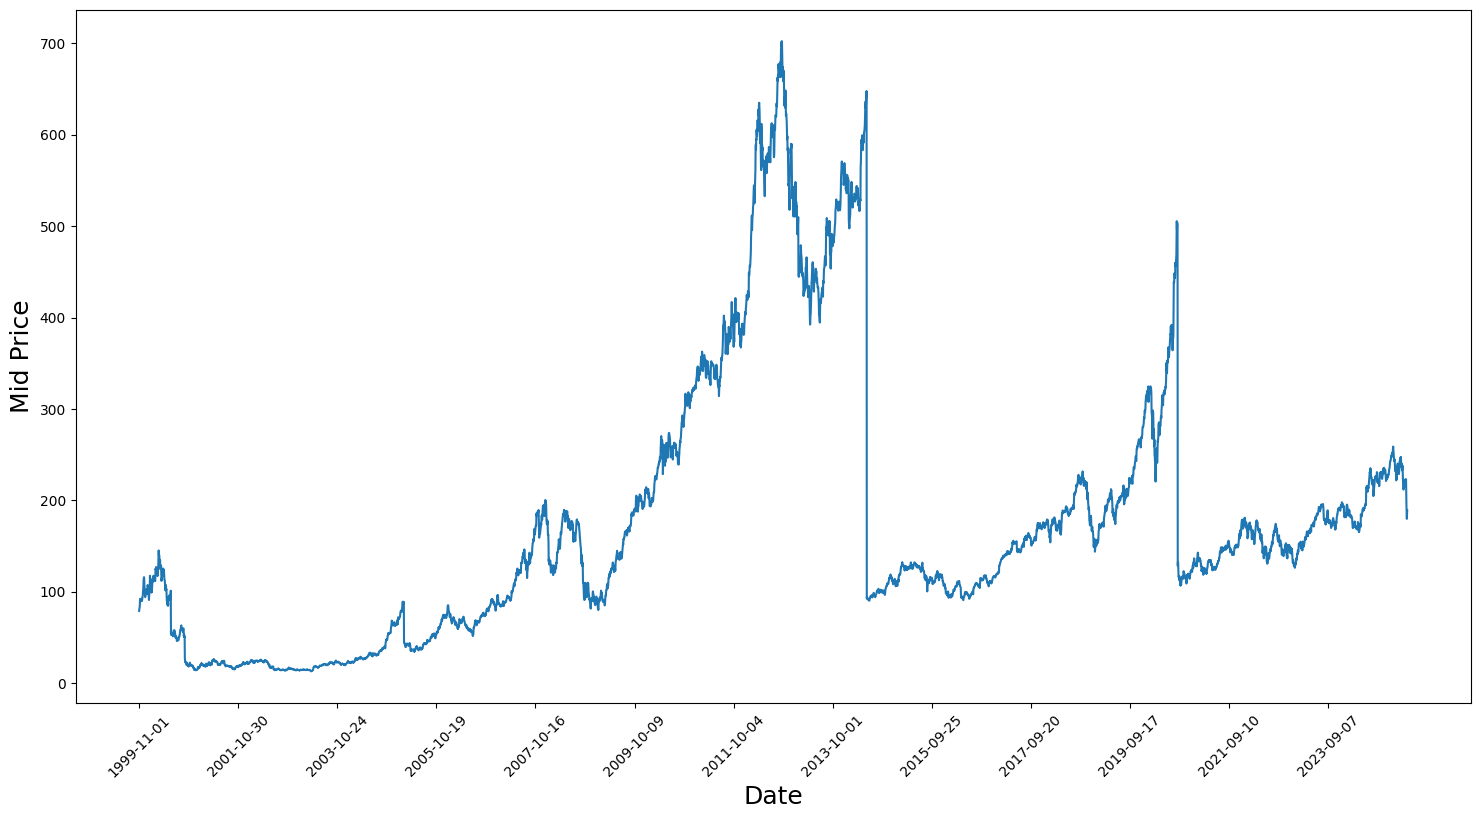

In [10]:
plt.figure(figsize=(18,9))
plt.plot(range(df.shape[0]), (df['Low']+df['High'])/2.0)
plt.xticks(range(0,df.shape[0],500),df['Date'].loc[::500],rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Mid Price',fontsize=18)
plt.show()

In [11]:
df.isnull().sum()

Date     0
Low      0
High     0
Close    0
Open     0
dtype: int64

In [12]:
duplicated = df[df.duplicated()]
duplicated

,Date,Low,High,Close,Open


In [13]:
df.describe()

,Low,High,Close,Open
count,6400.000000,6400.000000,6400.000000,6400.000000
mean,173.243174,177.222326,175.294765,175.275529
std,144.590613,147.192207,145.928217,145.987888
min,12.720000,13.190000,13.120000,12.990000
25%,80.392500,83.512500,82.297500,81.922500
50%,139.815000,143.332500,141.595000,141.590000
75%,207.252500,211.917500,209.210000,209.347500
max,699.570000,705.070000,702.100000,702.410000


In [14]:
df.head()

,Date,Low,High,Close,Open
0,1999-11-01,77.37,80.69,77.62,80.00
1,1999-11-02,77.31,81.69,80.25,78.00
2,1999-11-03,81.00,83.25,81.50,81.62
3,1999-11-04,80.62,85.37,83.62,82.06
4,1999-11-05,84.00,88.37,88.31,84.62


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6400 non-null   object 
 1   Low     6400 non-null   float64
 2   High    6400 non-null   float64
 3   Close   6400 non-null   float64
 4   Open    6400 non-null   float64
dtypes: float64(4), object(1)
memory usage: 250.1+ KB


In [16]:
highPrices = np.array(df.loc[:,'High'])
lowPrices = np.array(df.loc[:,'Low'])
midPrices = (highPrices+lowPrices)/2.0

In [17]:
midPrices

array([ 79.03   ,  79.5    ,  82.125  , ..., 179.77255, 186.25   ,
       188.88995])

In [18]:
train_data = midPrices[:int(len(midPrices)*0.8)]
test_data = midPrices[int(len(midPrices)*0.8): len(midPrices)]

print(f"train data count : {len(train_data)}")
print(f"test data count : {len(test_data)}")

train data count : 5120
test data count : 1280


In [19]:
scaler = MinMaxScaler()
train_data = train_data.reshape(-1,1)
test_data = test_data.reshape(-1,1)

In [20]:
print(train_data.shape)
print(test_data.shape)


(5120, 1)
(1280, 1)


In [21]:
windowSize = 1000
for di in range(0,5000,windowSize):
    scaler.fit(train_data[di: di+windowSize,:])
    train_data[di: di+windowSize, :] = scaler.transform(train_data[di:di+windowSize,:])


# rest of data

scaler.fit(train_data[di+windowSize:,:])
train_data[di+windowSize:,:] = scaler.transform(train_data[di+windowSize:,:])

In [22]:
train_data.shape

(5120, 1)

In [23]:
train_data = train_data.reshape(-1)
test_data = scaler.transform(test_data).reshape(-1)


In [24]:
train_data.shape

(5120,)

In [25]:
Ema = 0.0
gamma = 0.1

for i in range(len(train_data)):
    Ema = gamma*train_data[i] + (1-gamma)*Ema
    train_data[i] = Ema

all_mid_data = np.concatenate([train_data,test_data], axis=0)
all_mid_data

array([ 0.04995651,  0.09527287,  0.13804315, ..., -0.35855771,
       -0.29787334, -0.27314081])

In [26]:
windowSize = 100
n = train_data.size
std_avg_predictions = []
std_avg_x = []
mse_error =[]

for pred_idx in range(windowSize, n):
    if pred_idx >= n:
        date = dt.datetime.strptime(k,'%Y-%m-%d'.date() + dt.timedelta(days=1))
    else:
        date = df.loc[pred_idx,"Date"]

    std_avg_predictions.append(np.mean(train_data[pred_idx-windowSize:pred_idx]))
    mse_error.append((std_avg_predictions[-1]-train_data[pred_idx])**2)
    std_avg_x.append(date)

print('MSE error for standard averaging: %.5f'%(0.5*np.mean(mse_error)))



MSE error for standard averaging: 0.00803


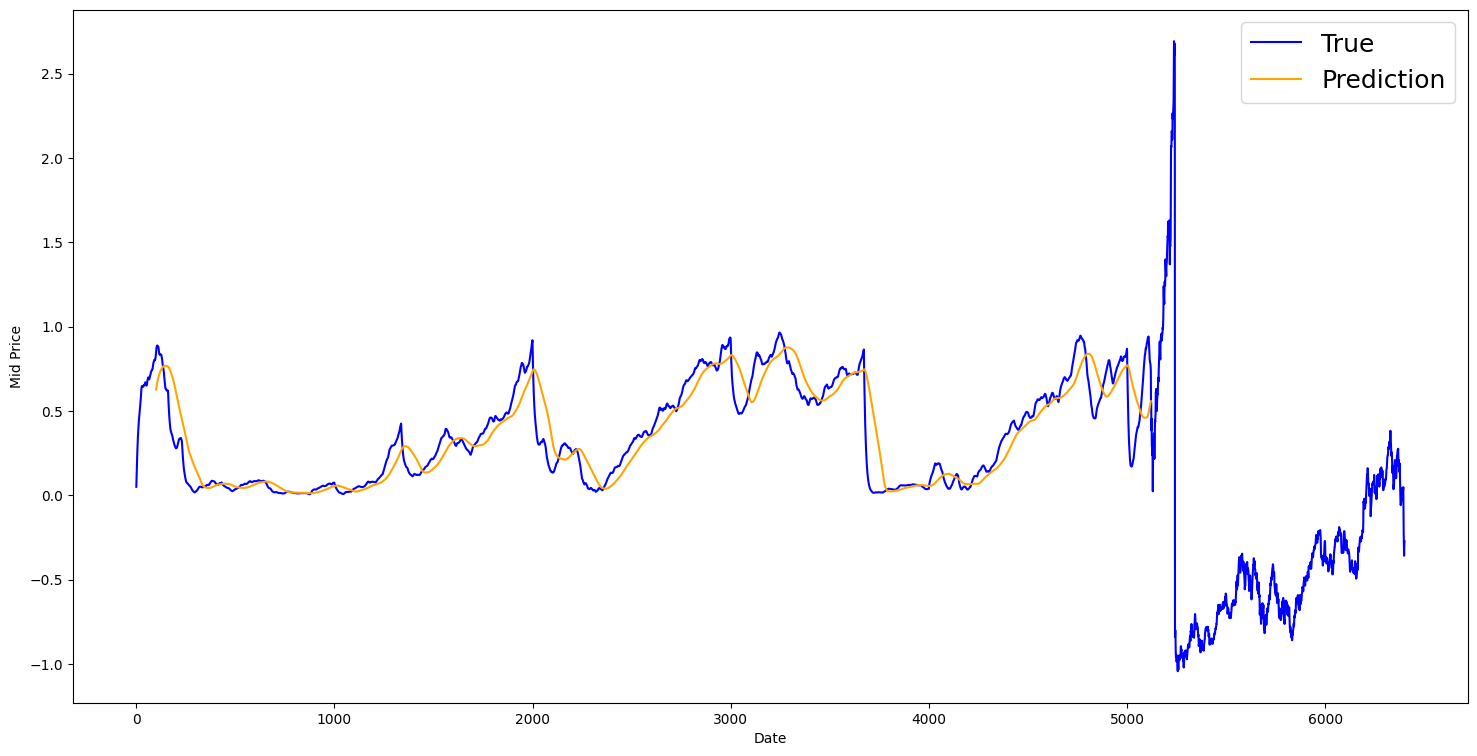

In [27]:
plt.figure(figsize = (18,9))
plt.plot(range(df.shape[0]),all_mid_data,color='b',label='True')
plt.plot(range(windowSize,n),std_avg_predictions,color='orange',label='Prediction')
#plt.xticks(range(0,df.shape[0],50),df['Date'].loc[::50],rotation=45)
plt.xlabel('Date')
plt.ylabel('Mid Price')
plt.legend(fontsize=18)
plt.show()

In [28]:
windowSize = 100
n = train_data.size

run_avg_predictions = []
run_avg_x = []

mse_error = []

running_mean = 0.0
run_avg_predictions.append(running_mean)

decay = 0.5

for pred_idx in range(1,n):

    running_mean = running_mean*decay + (1.0-decay)*train_data[pred_idx-1]
    run_avg_predictions.append(running_mean)
    mse_error.append((run_avg_predictions[-1]-train_data[pred_idx])**2)
    run_avg_x.append(date)

print('MSE error for EMA averaging: %.5f'%(0.5*np.mean(mse_error)))

MSE error for EMA averaging: 0.00007


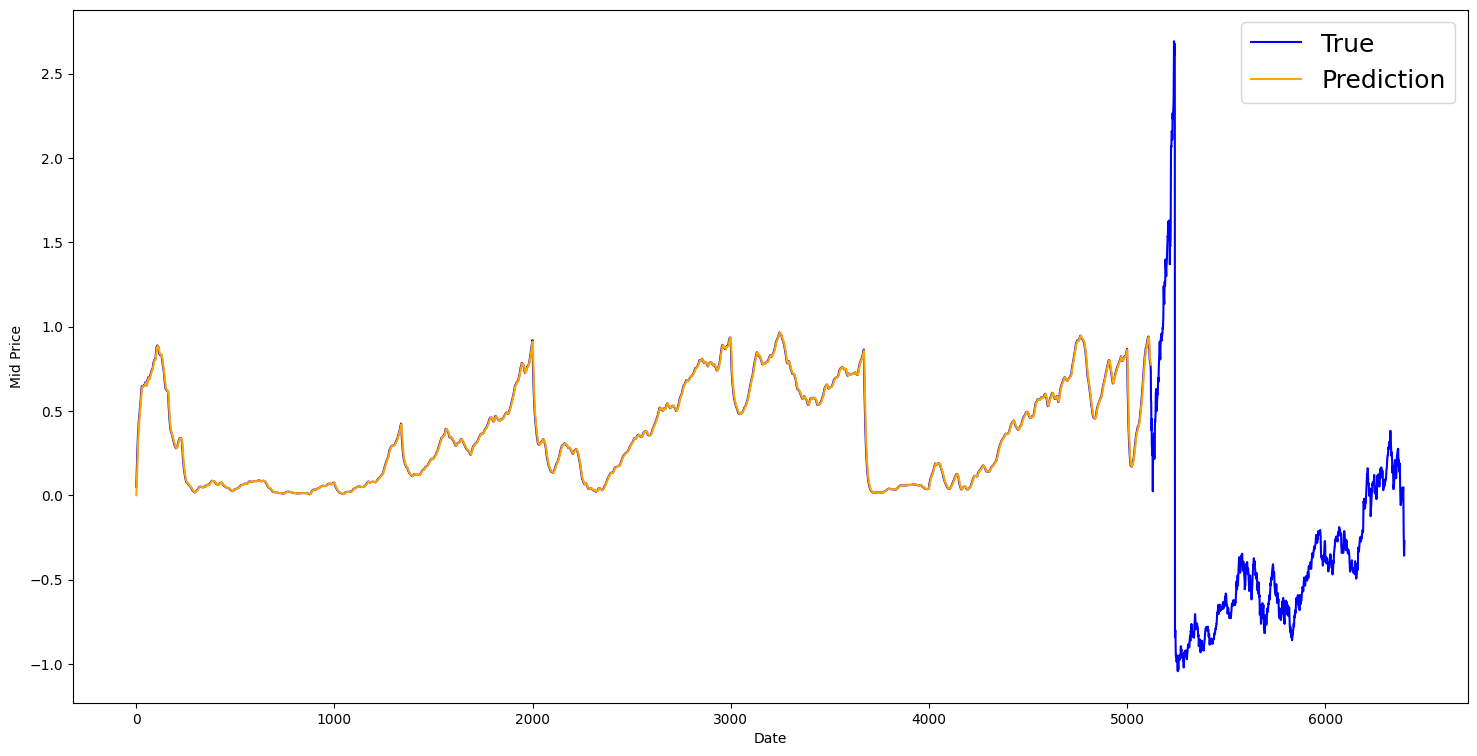

In [29]:

plt.figure(figsize = (18,9))
plt.plot(range(df.shape[0]),all_mid_data,color='b',label='True')
plt.plot(range(0,n),run_avg_predictions,color='orange', label='Prediction')
#plt.xticks(range(0,df.shape[0],50),df['Date'].loc[::50],rotation=45)
plt.xlabel('Date')
plt.ylabel('Mid Price')
plt.legend(fontsize=18)
plt.show()


In [30]:
class DataGeneratorSeq(object):

    def __init__(self, prices, batch_size, num_unroll):
        self._prices = prices
        self._prices_length = len(self._prices) - num_unroll
        self._batch_size = batch_size
        self._num_unroll = num_unroll
        self._segments = self._prices_length // self._batch_size
        self._cursor =  [offset * self._segments for offset in range(self._batch_size)]

    def next_batch(self):

        batch_data= np.zeros((self._batch_size), dtype= np.float32)
        batch_labels = np.zeros((self._batch_size), dtype= np.float32)

        for b in range(self._batch_size):
            if self._cursor[b]+1>=self._prices_length:
                self._cursor[b] = np.random.randint(0,(b+1)*self._segments)

            batch_data[b] = self._prices[self._cursor[b]]
            batch_labels[b]= self._prices[self._cursor[b]+np.random.randint(0,5)]

            self._cursor[b] = (self._cursor[b]+1)%self._prices_length

        return batch_data, batch_labels


    def unroll_batches(self):
        unroll_data, unroll_labels = [],[]
        init_data, init_label = None,None
        for ui in range(self._num_unroll):

            data, labels = self.next_batch()    

            unroll_data.append(data)
            unroll_labels.append(labels)

        return unroll_data, unroll_labels

    def reset_indices(self):
        for b in range(self._batch_size):
            self._cursor[b] = np.random.randint(0,min((b+1)*self._segments,self._prices_length-1))

    
dg = DataGeneratorSeq(train_data,5,5)
u_data, u_labels = dg.unroll_batches()

for ui,(dat,lbl) in enumerate(zip(u_data,u_labels)):   
    print('\n\nUnrolled index %d'%ui)
    dat_ind = dat
    lbl_ind = lbl
    print('\tInputs: ',dat )
    print('\n\tOutput:',lbl)






Unrolled index 0
	Inputs:  [0.04995651 0.01721081 0.3146572  0.520978   0.04676132]

	Output: [0.09527287 0.01631009 0.31945083 0.52269685 0.04676132]


Unrolled index 1
	Inputs:  [0.09527287 0.01631009 0.3163743  0.52269685 0.04499732]

	Output: [0.09527287 0.01572549 0.3261859  0.52772063 0.03920542]


Unrolled index 2
	Inputs:  [0.13804315 0.01592134 0.31945083 0.52504766 0.04361571]

	Output: [0.17719448 0.01537845 0.32276285 0.53029853 0.03876169]


Unrolled index 3
	Inputs:  [0.17719448 0.01572549 0.32276285 0.52772063 0.04125712]

	Output: [0.28717673 0.0135829  0.3289224  0.52772063 0.03876169]


Unrolled index 4
	Inputs:  [0.21484359 0.01537845 0.3261859  0.53029853 0.03920542]

	Output: [0.21484359 0.01306506 0.3289224  0.5333429  0.04018026]


In [31]:
D = 1 # Dimensionality of the data. Since your data is 1-D this would be 1
num_unrollings = 50 # Number of time steps you look into the future.
batch_size = 500 # Number of samples in a batch
num_nodes = [200,200,150] # Number of hidden nodes in each layer of the deep LSTM stack we're using
n_layers = len(num_nodes) # number of layers
dropout = 0.2 # dropout amount


In [ ]:
train_inputs, train_outputs = [],[]

for ui in range(num_unrollings):
    train_inputs.append(tf.placeholder(tf.float32, shape=[batch_size,D], name = 'train_inputs_%d'%ui))
    train_outputs.append(tf.placeholder(tf.float32, shape=[batch_size,1], name = 'train_outputs_%d'%ui))

AttributeError: module 'tensorflow' has no attribute 'placeholder'

In [ ]:
lstm_cells = [
    tf.contrib.rnn.LSTMCell(num_units=num_nodes[li],
                            state_is_tuple=True,
                            initializer= tf.contrib.layers.xavier_initializer()
                           )
 for li in range(n_layers)]

drop_lstm_cells = [tf.contrib.rnn.DropoutWrapper(
    lstm, input_keep_prob=1.0,output_keep_prob=1.0-dropout, state_keep_prob=1.0-dropout
) for lstm in lstm_cells]
drop_multi_cell = tf.contrib.rnn.MultiRNNCell(drop_lstm_cells)
multi_cell = tf.contrib.rnn.MultiRNNCell(lstm_cells)

w = tf.get_variable('w',shape=[num_nodes[-1], 1], initializer=tf.contrib.layers.xavier_initializer())
b = tf.get_variable('b',initializer=tf.random_uniform([1],-0.1,0.1))


In [33]:
# Create cell state and hidden state variables to maintain the state of the LSTM
c, h = [],[]
initial_state = []
for li in range(n_layers):
  c.append(tf.Variable(tf.zeros([batch_size, num_nodes[li]]), trainable=False))
  h.append(tf.Variable(tf.zeros([batch_size, num_nodes[li]]), trainable=False))
  initial_state.append(tf.contrib.rnn.LSTMStateTuple(c[li], h[li]))

# Do several tensor transofmations, because the function dynamic_rnn requires the output to be of
# a specific format. Read more at: https://www.tensorflow.org/api_docs/python/tf/nn/dynamic_rnn
all_inputs = tf.concat([tf.expand_dims(t,0) for t in train_inputs],axis=0)

# all_outputs is [seq_length, batch_size, num_nodes]
all_lstm_outputs, state = tf.nn.dynamic_rnn(
    drop_multi_cell, all_inputs, initial_state=tuple(initial_state),
    time_major = True, dtype=tf.float32)

all_lstm_outputs = tf.reshape(all_lstm_outputs, [batch_size*num_unrollings,num_nodes[-1]])

all_outputs = tf.nn.xw_plus_b(all_lstm_outputs,w,b)

split_outputs = tf.split(all_outputs,num_unrollings,axis=0)


AttributeError: module 'tensorflow' has no attribute 'contrib'

In [ ]:
# When calculating the loss you need to be careful about the exact form, because you calculate
# loss of all the unrolled steps at the same time
# Therefore, take the mean error or each batch and get the sum of that over all the unrolled steps

print('Defining training Loss')
loss = 0.0
with tf.control_dependencies([tf.assign(c[li], state[li][0]) for li in range(n_layers)]+
                             [tf.assign(h[li], state[li][1]) for li in range(n_layers)]):
  for ui in range(num_unrollings):
    loss += tf.reduce_mean(0.5*(split_outputs[ui]-train_outputs[ui])**2)

print('Learning rate decay operations')
global_step = tf.Variable(0, trainable=False)
inc_gstep = tf.assign(global_step,global_step + 1)
tf_learning_rate = tf.placeholder(shape=None,dtype=tf.float32)
tf_min_learning_rate = tf.placeholder(shape=None,dtype=tf.float32)

learning_rate = tf.maximum(
    tf.train.exponential_decay(tf_learning_rate, global_step, decay_steps=1, decay_rate=0.5, staircase=True),
    tf_min_learning_rate)

# Optimizer.
print('TF Optimization operations')
optimizer = tf.train.AdamOptimizer(learning_rate)
gradients, v = zip(*optimizer.compute_gradients(loss))
gradients, _ = tf.clip_by_global_norm(gradients, 5.0)
optimizer = optimizer.apply_gradients(
    zip(gradients, v))

print('\tAll done')


In [ ]:
print('Defining prediction related TF functions')

sample_inputs = tf.placeholder(tf.float32, shape=[1,D])

# Maintaining LSTM state for prediction stage
sample_c, sample_h, initial_sample_state = [],[],[]
for li in range(n_layers):
  sample_c.append(tf.Variable(tf.zeros([1, num_nodes[li]]), trainable=False))
  sample_h.append(tf.Variable(tf.zeros([1, num_nodes[li]]), trainable=False))
  initial_sample_state.append(tf.contrib.rnn.LSTMStateTuple(sample_c[li],sample_h[li]))

reset_sample_states = tf.group(*[tf.assign(sample_c[li],tf.zeros([1, num_nodes[li]])) for li in range(n_layers)],
                               *[tf.assign(sample_h[li],tf.zeros([1, num_nodes[li]])) for li in range(n_layers)])

sample_outputs, sample_state = tf.nn.dynamic_rnn(multi_cell, tf.expand_dims(sample_inputs,0),
                                   initial_state=tuple(initial_sample_state),
                                   time_major = True,
                                   dtype=tf.float32)

with tf.control_dependencies([tf.assign(sample_c[li],sample_state[li][0]) for li in range(n_layers)]+
                              [tf.assign(sample_h[li],sample_state[li][1]) for li in range(n_layers)]):  
  sample_prediction = tf.nn.xw_plus_b(tf.reshape(sample_outputs,[1,-1]), w, b)

print('\tAll done')


In [ ]:
epochs = 30
valid_summary = 1 # Interval you make test predictions

n_predict_once = 50 # Number of steps you continously predict for

train_seq_length = train_data.size # Full length of the training data

train_mse_ot = [] # Accumulate Train losses
test_mse_ot = [] # Accumulate Test loss
predictions_over_time = [] # Accumulate predictions

session = tf.InteractiveSession()

tf.global_variables_initializer().run()

# Used for decaying learning rate
loss_nondecrease_count = 0
loss_nondecrease_threshold = 2 # If the test error hasn't increased in this many steps, decrease learning rate

print('Initialized')
average_loss = 0

# Define data generator
data_gen = DataGeneratorSeq(train_data,batch_size,num_unrollings)

x_axis_seq = []

# Points you start your test predictions from
test_points_seq = np.arange(11000,12000,50).tolist()

for ep in range(epochs):       

    # ========================= Training =====================================
    for step in range(train_seq_length//batch_size):

        u_data, u_labels = data_gen.unroll_batches()

        feed_dict = {}
        for ui,(dat,lbl) in enumerate(zip(u_data,u_labels)):            
            feed_dict[train_inputs[ui]] = dat.reshape(-1,1)
            feed_dict[train_outputs[ui]] = lbl.reshape(-1,1)

        feed_dict.update({tf_learning_rate: 0.0001, tf_min_learning_rate:0.000001})

        _, l = session.run([optimizer, loss], feed_dict=feed_dict)

        average_loss += l

    # ============================ Validation ==============================
    if (ep+1) % valid_summary == 0:

      average_loss = average_loss/(valid_summary*(train_seq_length//batch_size))

      # The average loss
      if (ep+1)%valid_summary==0:
        print('Average loss at step %d: %f' % (ep+1, average_loss))

      train_mse_ot.append(average_loss)

      average_loss = 0 # reset loss

      predictions_seq = []

      mse_test_loss_seq = []

      # ===================== Updating State and Making Predicitons ========================
      for w_i in test_points_seq:
        mse_test_loss = 0.0
        our_predictions = []

        if (ep+1)-valid_summary==0:
          # Only calculate x_axis values in the first validation epoch
          x_axis=[]

        # Feed in the recent past behavior of stock prices
        # to make predictions from that point onwards
        for tr_i in range(w_i-num_unrollings+1,w_i-1):
          current_price = all_mid_data[tr_i]
          feed_dict[sample_inputs] = np.array(current_price).reshape(1,1)    
          _ = session.run(sample_prediction,feed_dict=feed_dict)

        feed_dict = {}

        current_price = all_mid_data[w_i-1]

        feed_dict[sample_inputs] = np.array(current_price).reshape(1,1)

        # Make predictions for this many steps
        # Each prediction uses previous prediciton as it's current input
        for pred_i in range(n_predict_once):

          pred = session.run(sample_prediction,feed_dict=feed_dict)

          our_predictions.append(np.asscalar(pred))

          feed_dict[sample_inputs] = np.asarray(pred).reshape(-1,1)

          if (ep+1)-valid_summary==0:
            # Only calculate x_axis values in the first validation epoch
            x_axis.append(w_i+pred_i)

          mse_test_loss += 0.5*(pred-all_mid_data[w_i+pred_i])**2

        session.run(reset_sample_states)

        predictions_seq.append(np.array(our_predictions))

        mse_test_loss /= n_predict_once
        mse_test_loss_seq.append(mse_test_loss)

        if (ep+1)-valid_summary==0:
          x_axis_seq.append(x_axis)

      current_test_mse = np.mean(mse_test_loss_seq)

      # Learning rate decay logic
      if len(test_mse_ot)>0 and current_test_mse > min(test_mse_ot):
          loss_nondecrease_count += 1
      else:
          loss_nondecrease_count = 0

      if loss_nondecrease_count > loss_nondecrease_threshold :
            session.run(inc_gstep)
            loss_nondecrease_count = 0
            print('\tDecreasing learning rate by 0.5')

      test_mse_ot.append(current_test_mse)
      print('\tTest MSE: %.5f'%np.mean(mse_test_loss_seq))
      predictions_over_time.append(predictions_seq)
      print('\tFinished Predictions')


In [ ]:
best_prediction_epoch = 28 # replace this with the epoch that you got the best results when running the plotting code

plt.figure(figsize = (18,18))
plt.subplot(2,1,1)
plt.plot(range(df.shape[0]),all_mid_data,color='b')

# Plotting how the predictions change over time
# Plot older predictions with low alpha and newer predictions with high alpha
start_alpha = 0.25
alpha  = np.arange(start_alpha,1.1,(1.0-start_alpha)/len(predictions_over_time[::3]))
for p_i,p in enumerate(predictions_over_time[::3]):
    for xval,yval in zip(x_axis_seq,p):
        plt.plot(xval,yval,color='r',alpha=alpha[p_i])

plt.title('Evolution of Test Predictions Over Time',fontsize=18)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Mid Price',fontsize=18)
plt.xlim(11000,12500)

plt.subplot(2,1,2)

# Predicting the best test prediction you got
plt.plot(range(df.shape[0]),all_mid_data,color='b')
for xval,yval in zip(x_axis_seq,predictions_over_time[best_prediction_epoch]):
    plt.plot(xval,yval,color='r')

plt.title('Best Test Predictions Over Time',fontsize=18)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Mid Price',fontsize=18)
plt.xlim(11000,12500)
plt.show()